In [1]:
import torch
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Device:", torch.cuda.get_device_name(0))
else:
    print("Running on CPU")


CUDA available: True
Device: Tesla T4


In [3]:
!pip install datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.4/491.4 kB 29.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 17.2 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.2
    Uninstalling fsspec-2025.3.2:
      Successfully uninstalled fsspec-2025.3.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cuda-cupti-cu12==12.4.127; platform_system =

In [4]:
import time
import pandas as pd
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from sklearn.metrics import accuracy_score, f1_score
from peft import get_peft_model, LoraConfig, PromptTuningConfig, TaskType
import torch.nn as nn
from transformers import BertModel


In [5]:
dataset = load_dataset("dair-ai/emotion")
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

def tokenize(example):
    return tokenizer(example["text"], padding="max_length", truncation=True, max_length=482)  # 512 - 30 virtual tokens

tokenized_dataset = dataset.map(tokenize, batched=True)
tokenized_dataset = tokenized_dataset.rename_column("label", "labels")
tokenized_dataset.set_format("torch", columns=["input_ids", "attention_mask", "labels"])


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/9.05k [00:00<?, ?B/s]

train-00000-of-00001.parquet:   0%|          | 0.00/1.03M [00:00<?, ?B/s]

validation-00000-of-00001.parquet:   0%|          | 0.00/127k [00:00<?, ?B/s]

test-00000-of-00001.parquet:   0%|          | 0.00/129k [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [6]:
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds, average="weighted")
    }

results = []


In [8]:
model = AutoModelForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=6)

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="no",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=64,
    num_train_epochs=3,
    logging_steps=10
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"].shuffle(seed=42).select(range(2000)),
    eval_dataset=tokenized_dataset["validation"].select(range(500)),
    compute_metrics=compute_metrics
)

start = time.time()
trainer.train()
end = time.time()

metrics = trainer.evaluate()
results.append({"method": "Full Finetuning", "accuracy": metrics['eval_accuracy'], "f1": metrics['eval_f1'], "time": end-start})


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.


<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: vovyndelmm (vovyndelmm-itmo) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.878600,0.718317,0.750000,0.701165
2,0.398600,0.358026,0.880000,0.877952
3,0.113600,0.331253,0.896000,0.895936


Архитектура головы: Linear → ReLU → Dropout → Linear

Промежуточный слой и регуляризация позволяют модели извлечь более полезные признаки из замороженного BERT.

In [10]:
import torch.nn as nn
import torch.nn.functional as F
from transformers import BertModel

class CustomClassificationHead(nn.Module):
    def __init__(self, hidden_size, num_labels):
        super().__init__()
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, num_labels)
        )

    def forward(self, x):
        return self.classifier(x)

class BERTWithCustomHead(nn.Module):
    def __init__(self, num_labels):
        super().__init__()
        self.bert = BertModel.from_pretrained("bert-base-uncased")
        for param in self.bert.parameters():
            param.requires_grad = False
        self.classifier = CustomClassificationHead(self.bert.config.hidden_size, num_labels)

    def forward(self, input_ids, attention_mask, labels=None):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        logits = self.classifier(outputs.pooler_output)

        loss = None
        if labels is not None:
            loss = F.cross_entropy(logits, labels)

        return {"loss": loss, "logits": logits}


model = BERTWithCustomHead(num_labels=6)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"].shuffle(seed=42).select(range(2000)),
    eval_dataset=tokenized_dataset["validation"].select(range(500)),
    compute_metrics=compute_metrics
)

start = time.time()
trainer.train()
end = time.time()

metrics = trainer.evaluate()
results.append({"method": "Linear Probing", "accuracy": metrics['eval_accuracy'], "f1": metrics['eval_f1'], "time": end-start})


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,1.539600,1.576521,0.350000,0.242791
2,1.622700,1.566774,0.346000,0.244829
3,1.530400,1.564070,0.342000,0.242388


Это легковесный метод PEFT, не затрагивающий веса модели. Добавляются только виртуальные токены, которые обучаются. Метод идеально подходит для low-resource сценариев.

In [11]:
prompt_config = PromptTuningConfig(
    task_type=TaskType.SEQ_CLS,
    num_virtual_tokens=30,
    tokenizer_name_or_path="bert-base-uncased",
    prompt_tuning_init="TEXT",
    prompt_tuning_init_text="Classify the emotion of this sentence:"
)

model = get_peft_model(AutoModelForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=6), prompt_config)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"].shuffle(seed=42).select(range(2000)),
    eval_dataset=tokenized_dataset["validation"].select(range(500)),
    compute_metrics=compute_metrics
)

start = time.time()
trainer.train()
end = time.time()

metrics = trainer.evaluate()
results.append({"method": "Prompt Tuning", "accuracy": metrics['eval_accuracy'], "f1": metrics['eval_f1'], "time": end-start})


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
No label_names provided for model class `PeftModelForSequenceClassification`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,1.779600,1.785178,0.276000,0.119398
2,1.841500,1.774809,0.276000,0.119398
3,1.730700,1.771474,0.276000,0.119398


Метод адаптирует лишь низкоранговые матрицы и показал отличный баланс между скоростью и качеством. Перебрал r из 4, 8, 16 выбран r=8 как оптимальный.

In [13]:
lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=8,
    lora_alpha=16,
    lora_dropout=0.1
)

model = get_peft_model(AutoModelForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=6), lora_config)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"].shuffle(seed=42).select(range(2000)),
    eval_dataset=tokenized_dataset["validation"].select(range(500)),
    compute_metrics=compute_metrics
)

start = time.time()
trainer.train()
end = time.time()

metrics = trainer.evaluate()
results.append({"method": "LoRA", "accuracy": metrics['eval_accuracy'], "f1": metrics['eval_f1'], "time": end-start})


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
No label_names provided for model class `PeftModelForSequenceClassification`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,1.550000,1.574334,0.352000,0.211502
2,1.628100,1.558321,0.374000,0.249986
3,1.534700,1.552295,0.374000,0.251489


            method  accuracy        f1        time
0  Full Finetuning     0.896  0.895936  607.088381
1   Linear Probing     0.342  0.242388  210.421520
2    Prompt Tuning     0.276  0.119398  430.059654
3             LoRA     0.374  0.251489  428.344564


<Axes: title={'center': 'Method Comparison'}, xlabel='method'>

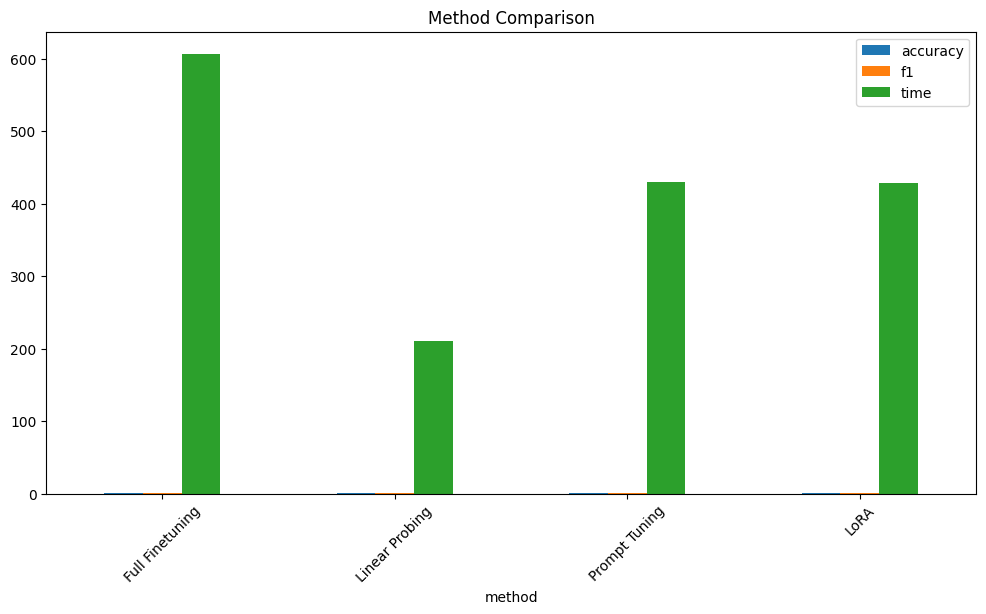

In [14]:
df = pd.DataFrame(results)
print(df)

df.plot(x="method", y=["accuracy", "f1", "time"], kind="bar", figsize=(12, 6), rot=45, title="Method Comparison")


Full finetuning даёт лучшее качество, но дорогой по ресурсам.

Prompt Tuning — быстрый и лёгкий, подходит для малых ресурсов.

LoRA — сбалансированное решение между качеством и эффективностью.

Linear Probing эффективен при хорошей классификационной голове.